# ASSIGNMENT 3

# TASK NUMBER 2

---



# **BY : BUSHRA ABAD & tAYYABA IMTIYAZ**



**LIBRARIES**


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# **Dataset Class**

In [ ]:
class CUHKDataset(Dataset):
    def __init__(self, sketch_dir, photo_dir, transform=None):
        self.sketch_dir = sketch_dir
        self.photo_dir = photo_dir
        self.transform = transform

        self.sketch_images = sorted(os.listdir(sketch_dir))
        self.photo_images = sorted(os.listdir(photo_dir))

    def __len__(self):
        return len(self.sketch_images)

    def __getitem__(self, idx):
        sketch_path = os.path.join(self.sketch_dir, self.sketch_images[idx])
        photo_path = os.path.join(self.photo_dir, self.photo_images[idx])

        sketch = Image.open(sketch_path).convert("RGB")
        photo = Image.open(photo_path).convert("RGB")

        if self.transform:
            sketch = self.transform(sketch)
            photo = self.transform(photo)

        return sketch, photo

# **Transformations**

In [ ]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# **DATA LOADING**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arbazkhan971/cuhk-face-sketch-database-cufs")

print("Path to dataset files:", path)




import kagglehub

# Download latest version
path = kagglehub.dataset_download("ktaebum/anime-sketch-colorization-pair")

print("Path to dataset files:", path)

100%|██████████| 113M/113M [00:00<00:00, 161MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1


100%|██████████| 11.6G/11.6G [01:55<00:00, 108MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ktaebum/anime-sketch-colorization-pair/versions/1


# **Generator (U-NET)**

In [ ]:
class UNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, down=True, use_dropout=False):
        super().__init__()
        if down:
            self.conv = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU(0.2)
            )
        else:
            self.conv = nn.Sequential(
                nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU()
            )

        self.use_dropout = use_dropout
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.conv(x)
        return self.dropout(x) if self.use_dropout else x

# Full Generator

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.down1 = nn.Conv2d(3, 64, 4, 2, 1)
        self.down2 = UNetBlock(64, 128)
        self.down3 = UNetBlock(128, 256)
        self.down4 = UNetBlock(256, 512)
        self.down5 = UNetBlock(512, 512)
        self.down6 = UNetBlock(512, 512)
        self.down7 = UNetBlock(512, 512)
        self.bottleneck = nn.Conv2d(512, 512, 4, 2, 1)

        # Decoder
        self.up1 = UNetBlock(512, 512, down=False, use_dropout=True)
        self.up2 = UNetBlock(1024, 512, down=False, use_dropout=True)
        self.up3 = UNetBlock(1024, 512, down=False, use_dropout=True)
        self.up4 = UNetBlock(1024, 512, down=False)
        self.up5 = UNetBlock(1024, 256, down=False)
        self.up6 = UNetBlock(512, 128, down=False)
        self.up7 = UNetBlock(256, 64, down=False)

        self.final = nn.ConvTranspose2d(128, 3, 4, 2, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        bottleneck = self.bottleneck(d7)

        u1 = self.up1(bottleneck)
        u2 = self.up2(torch.cat([u1, d7], dim=1))
        u3 = self.up3(torch.cat([u2, d6], dim=1))
        u4 = self.up4(torch.cat([u3, d5], dim=1))
        u5 = self.up5(torch.cat([u4, d4], dim=1))
        u6 = self.up6(torch.cat([u5, d3], dim=1))
        u7 = self.up7(torch.cat([u6, d2], dim=1))

        return torch.tanh(self.final(torch.cat([u7, d1], dim=1)))

# **Discriminator (PatchGAN)**

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 1, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, x, y):
        # concatenate input + target
        return self.model(torch.cat([x, y], dim=1))

# **Loss Functions**

### **Perceptual Loss (VGG Loss)**
To improve the generation of high-level features like eyes, nose, and mouth, we can use a perceptual loss. This loss measures the difference between the feature maps of the generated and target images, extracted from a pre-trained convolutional neural network (like VGG). This encourages the generator to produce outputs that are structurally and perceptually more similar to the real images, rather than just pixel-wise accurate.

In [ ]:
L1_LOSS = nn.L1Loss()
BCE_LOSS = nn.BCEWithLogitsLoss()

LAMBDA = 200

In [ ]:
import torchvision.models as models

class VGGFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        vgg16 = models.vgg16(pretrained=True)
        # Use features up to relu2_2 (index 9) for feature extraction
        self.features = nn.Sequential(*list(vgg16.features)[:9])
        # Freeze VGG parameters to prevent them from being trained
        for param in self.features.parameters():
            param.requires_grad = False

    def forward(self, x):
        # VGG expects 3-channel images, normalized with mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225]
        # Our images are currently normalized with mean=0.5, std=0.5.
        # We'll adapt by just passing the input as is, assuming VGG handles typical image ranges, or re-normalize if needed.
        # For simplicity, we'll assume VGG's initial layers are robust enough to handle the 0.5/0.5 normalization.
        return self.features(x)

vgg_feature_extractor = VGGFeatureExtractor().to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 97.4MB/s]


# **Optimizers**

In [ ]:
gen = Generator().to(device)
disc = Discriminator().to(device)

opt_gen = optim.Adam(gen.parameters(), lr=0.0001, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=0.0001, betas=(0.5, 0.999))

# **Training Loop**

In [ ]:
from torch.cuda.amp import autocast, GradScaler

cuhk_dataset_path = '/root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1'

sketch_dir = os.path.join(cuhk_dataset_path, 'sketches')
photo_dir = os.path.join(cuhk_dataset_path, 'photos')

# Initialize the dataset and dataloader
dataset = CUHKDataset(sketch_dir, photo_dir, transform)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"Dataset loaded with {len(dataset)} samples.")
print(f"Sketch directory: {sketch_dir}")
print(f"Photo directory: {photo_dir}")

scaler = GradScaler()

# Define LAMBDA for VGG Loss (perceptual loss)
LAMBDA_VGG = 10 # You can adjust this weight

# Initialize lists to store losses
gen_losses = []
disc_losses = []

for epoch in range(100):
    for idx, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)

        # Training Discriminator
        with autocast():
            y_fake = gen(x)

            D_real = disc(x, y)
            D_fake = disc(x, y_fake.detach())

            loss_D_real = BCE_LOSS(D_real, torch.ones_like(D_real))
            loss_D_fake = BCE_LOSS(D_fake, torch.zeros_like(D_fake))
            loss_D = (loss_D_real + loss_D_fake) / 2

        opt_disc.zero_grad()
        scaler.scale(loss_D).backward()
        scaler.step(opt_disc)

        # Training Generator

        with autocast():
            D_fake = disc(x, y_fake)
            loss_G_GAN = BCE_LOSS(D_fake, torch.ones_like(D_fake))
            loss_G_L1 = L1_LOSS(y_fake, y) * LAMBDA

            # Calculate VGG perceptual loss
            vgg_output_fake = vgg_feature_extractor(y_fake)
            vgg_output_real = vgg_feature_extractor(y)
            loss_G_VGG = L1_LOSS(vgg_output_fake, vgg_output_real.detach()) * LAMBDA_VGG

            loss_G = loss_G_GAN + loss_G_L1 + loss_G_VGG

        opt_gen.zero_grad()
        scaler.scale(loss_G).backward()
        scaler.step(opt_gen)
        scaler.update()

    gen_losses.append(loss_G.item())
    disc_losses.append(loss_D.item())
    print(f"Epoch {epoch} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

Dataset loaded with 188 samples.
Sketch directory: /root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1/sketches
Photo directory: /root/.cache/kagglehub/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/versions/1/photos


/tmp/ipykernel_7703/1332326019.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_7703/1332326019.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_7703/1332326019.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 0 | D Loss: 0.7176 | G Loss: 10.0607
Epoch 1 | D Loss: 0.6851 | G Loss: 8.8256
Epoch 2 | D Loss: 0.6199 | G Loss: 8.6207
Epoch 3 | D Loss: 0.6581 | G Loss: 8.9730
Epoch 4 | D Loss: 0.7898 | G Loss: 9.1836


/tmp/ipykernel_7703/1332326019.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_7703/1332326019.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5 | D Loss: 0.7856 | G Loss: 10.3109
Epoch 6 | D Loss: 0.5510 | G Loss: 8.9244
Epoch 7 | D Loss: 0.5155 | G Loss: 9.1798
Epoch 8 | D Loss: 1.4088 | G Loss: 10.7174
Epoch 9 | D Loss: 0.4594 | G Loss: 10.8527
Epoch 10 | D Loss: 0.4945 | G Loss: 8.5337
Epoch 11 | D Loss: 0.5809 | G Loss: 9.1265
Epoch 12 | D Loss: 0.5735 | G Loss: 9.0021
Epoch 13 | D Loss: 0.5030 | G Loss: 10.4000
Epoch 14 | D Loss: 0.3955 | G Loss: 9.9386
Epoch 15 | D Loss: 0.9311 | G Loss: 10.0022
Epoch 16 | D Loss: 0.4768 | G Loss: 10.8470
Epoch 17 | D Loss: 0.4829 | G Loss: 9.6833
Epoch 18 | D Loss: 0.5357 | G Loss: 10.8798
Epoch 19 | D Loss: 0.3086 | G Loss: 9.5324
Epoch 20 | D Loss: 0.7395 | G Loss: 8.4471
Epoch 21 | D Loss: 0.3775 | G Loss: 10.0802
Epoch 22 | D Loss: 0.6190 | G Loss: 8.2266
Epoch 23 | D Loss: 0.4973 | G Loss: 9.8182
Epoch 24 | D Loss: 0.2961 | G Loss: 10.9316
Epoch 25 | D Loss: 0.7743 | G Loss: 13.4227
Epoch 26 | D Loss: 0.4430 | G Loss: 10.3410
Epoch 27 | D Loss: 0.3837 | G Loss: 10.4076
Epoc

## Training Logs (Loss Graphs)

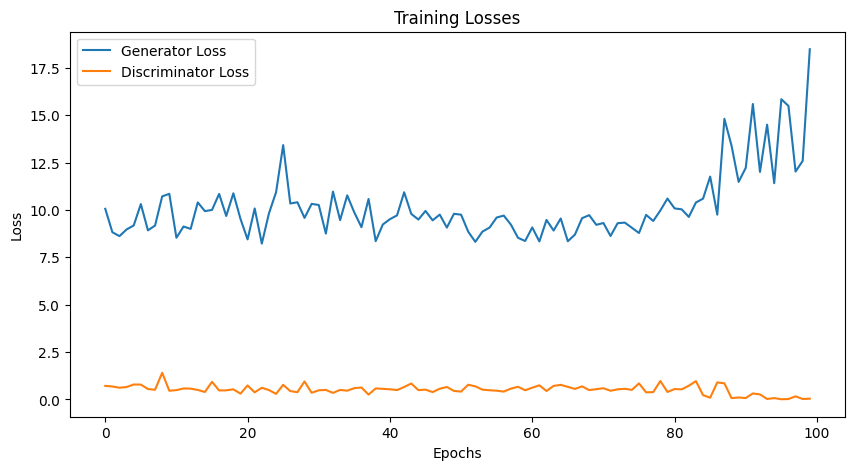

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(gen_losses, label="Generator Loss")
plt.plot(disc_losses, label="Discriminator Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Losses")
plt.show()

## SSIM (Structural Similarity Index) and PSNR (Peak Signal-to-Noise Ratio)

In [ ]:
!pip install scikit-image

In [ ]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

def calculate_ssim(real, fake):
    real = real.cpu().detach().numpy()
    fake = fake.cpu().detach().numpy()

    real = np.transpose(real, (0,2,3,1))
    fake = np.transpose(fake, (0,2,3,1))

    scores = []
    for i in range(real.shape[0]):

        score = ssim(real[i], fake[i], channel_axis=2, data_range=1.0)
        scores.append(score)

    return np.mean(scores)

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr

def calculate_psnr(real, fake):
    real = real.cpu().detach().numpy()
    fake = fake.cpu().detach().numpy()

    real = np.transpose(real, (0,2,3,1))
    fake = np.transpose(fake, (0,2,3,1))

    scores = []
    for i in range(real.shape[0]):
        # data_range=1.0 because pixel values are assumed to be in [0, 1]
        score = psnr(real[i], fake[i], data_range=1.0)
        scores.append(score)

    return np.mean(scores)

## Run Evaluation

In [ ]:
gen.eval()

x, y = next(iter(loader))
x, y = x.to(device), y.to(device)

with torch.no_grad():
    y_fake = gen(x)
y = (y + 1) / 2
y_fake = (y_fake + 1) / 2

ssim_score = calculate_ssim(y, y_fake)
psnr_score = calculate_psnr(y, y_fake)

print(f"SSIM: {ssim_score:.4f}")
print(f"PSNR: {psnr_score:.4f}")

SSIM: 0.8564
PSNR: 29.6081


# **Visualization**

In [ ]:
def show_images(gen, loader):
    gen.eval()
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)

    with torch.no_grad():
        y_fake = gen(x)

    fig, axs = plt.subplots(3, 5, figsize=(15, 8))

    for i in range(5):
        axs[0, i].imshow(x[i].permute(1,2,0).cpu()*0.5+0.5)
        axs[1, i].imshow(y_fake[i].permute(1,2,0).cpu()*0.5+0.5)
        axs[2, i].imshow(y[i].permute(1,2,0).cpu()*0.5+0.5)

    plt.show()


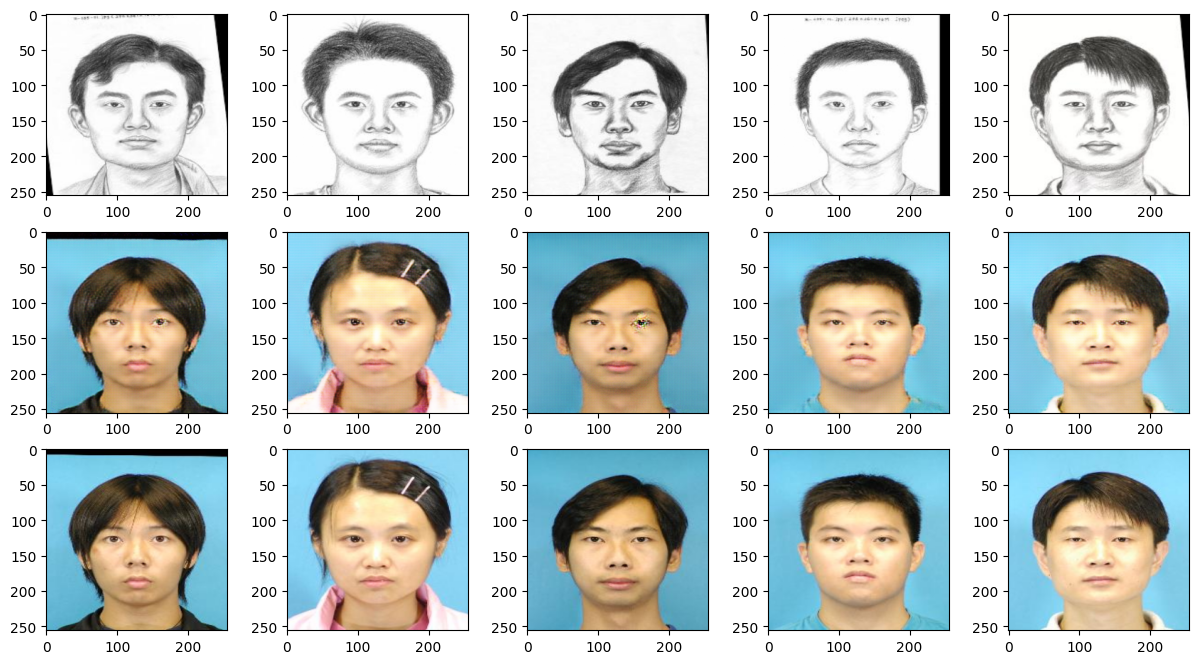

In [ ]:
show_images(gen, loader)

In [ ]:
model_save_path = 'generator_model.pth'
torch.save(gen.state_dict(), model_save_path)
print(f"Generator model saved to {model_save_path}")

Generator model saved to generator_model.pth


# **GRADIO APP**

In [ ]:
import gradio as gr
from PIL import Image

def predict_image(input_image):
    gen.eval()
    input_tensor = transform(input_image).unsqueeze(0).to(device)

    with torch.no_grad():
        output_tensor = gen(input_tensor)

    # Post-process the output tensor to a PIL Image
    output_image = output_tensor.squeeze(0).cpu()
    # De-normalize and convert to [0, 1] range for PIL
    output_image = output_image * 0.5 + 0.5
    output_image = transforms.ToPILImage()(output_image)
    return output_image

In [ ]:
iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload Sketch Image"),
    outputs=gr.Image(type="pil", label="Generated Photo"),
    title="Sketch to Photo Generation with GAN",
    description="Upload a sketch image and let the trained GAN generate a corresponding photo."
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8004d2f00edf78b028.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
